In [4]:
import graph_tool.all as gt
import numpy as np
import matplotlib.pyplot as plt

In [27]:
# create simple directed, weighted random graph
g = gt.random_graph(20, lambda: (1,1), directed=True)
eweight = g.new_edge_property("int")
for e in g.edges():
    eweight[e] = np.random.randint(1, 10)
g.edge_properties["weight"] = eweight

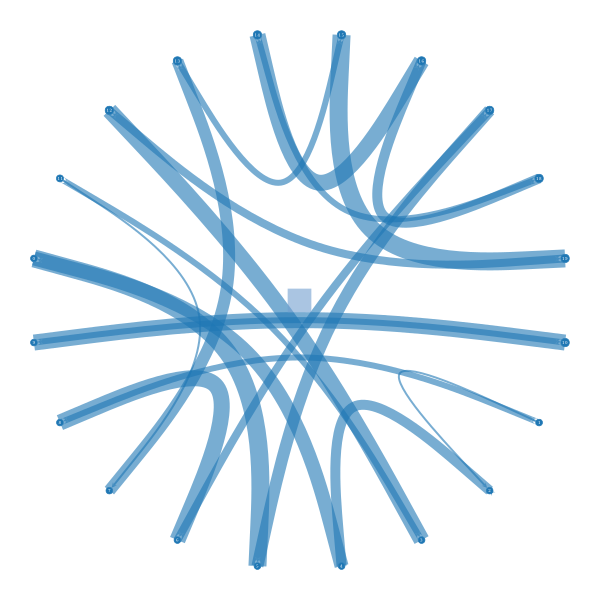

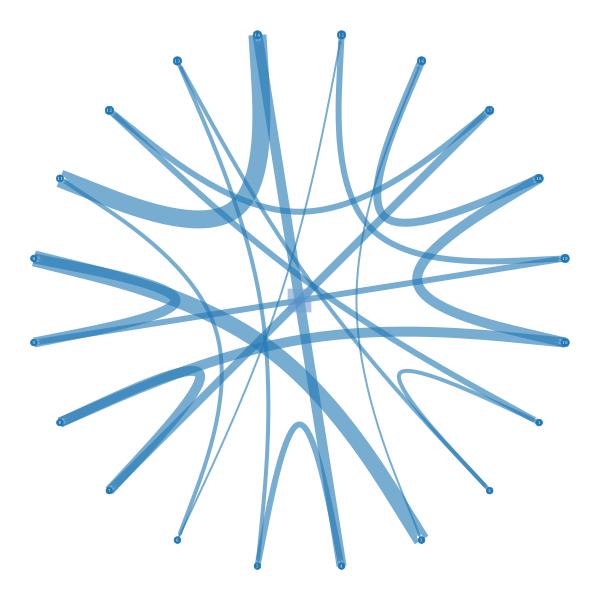

(<VertexPropertyMap object with value type 'vector<double>', for Graph 0x7fea8ceffa70, at 0x7fea84f37070>,
 <GraphView object, directed, with 21 vertices and 20 edges, edges filtered by <EdgePropertyMap object with value type 'bool', for Graph 0x7fea84f39b30, at 0x7fea84f36190>, vertices filtered by <VertexPropertyMap object with value type 'bool', for Graph 0x7fea84f39b30, at 0x7fea84f35fd0>, at 0x7fea84f39b30>,
 <VertexPropertyMap object with value type 'vector<double>', for Graph 0x7fea84f39b30, at 0x7fea84f35780>)

In [46]:
# draw the graph block state
state = gt.minimize_nested_blockmodel_dl(g)

pos, _, _ = state.draw(vertex_text=g.vertex_index, edge_pen_width=g.edge_properties["weight"], bg_color=(1, 1, 1, 1), output_size=(300, 300))

# now make a second graph with the same nodes but different edges
g2 = gt.random_graph(20, lambda: (1,1), directed=True)
eweight2 = g2.new_edge_property("int")
for e in g2.edges():
    eweight2[e] = np.random.randint(1, 10)
g2.edge_properties["weight"] = eweight2

# draw the second graph block state with the same layout as the first
state2 = gt.minimize_nested_blockmodel_dl(g2)
state2.draw(vertex_text=g2.vertex_index, edge_pen_width=g2.edge_properties["weight"], bg_color=(1, 1, 1, 1), output_size=(300, 300), pos=pos)

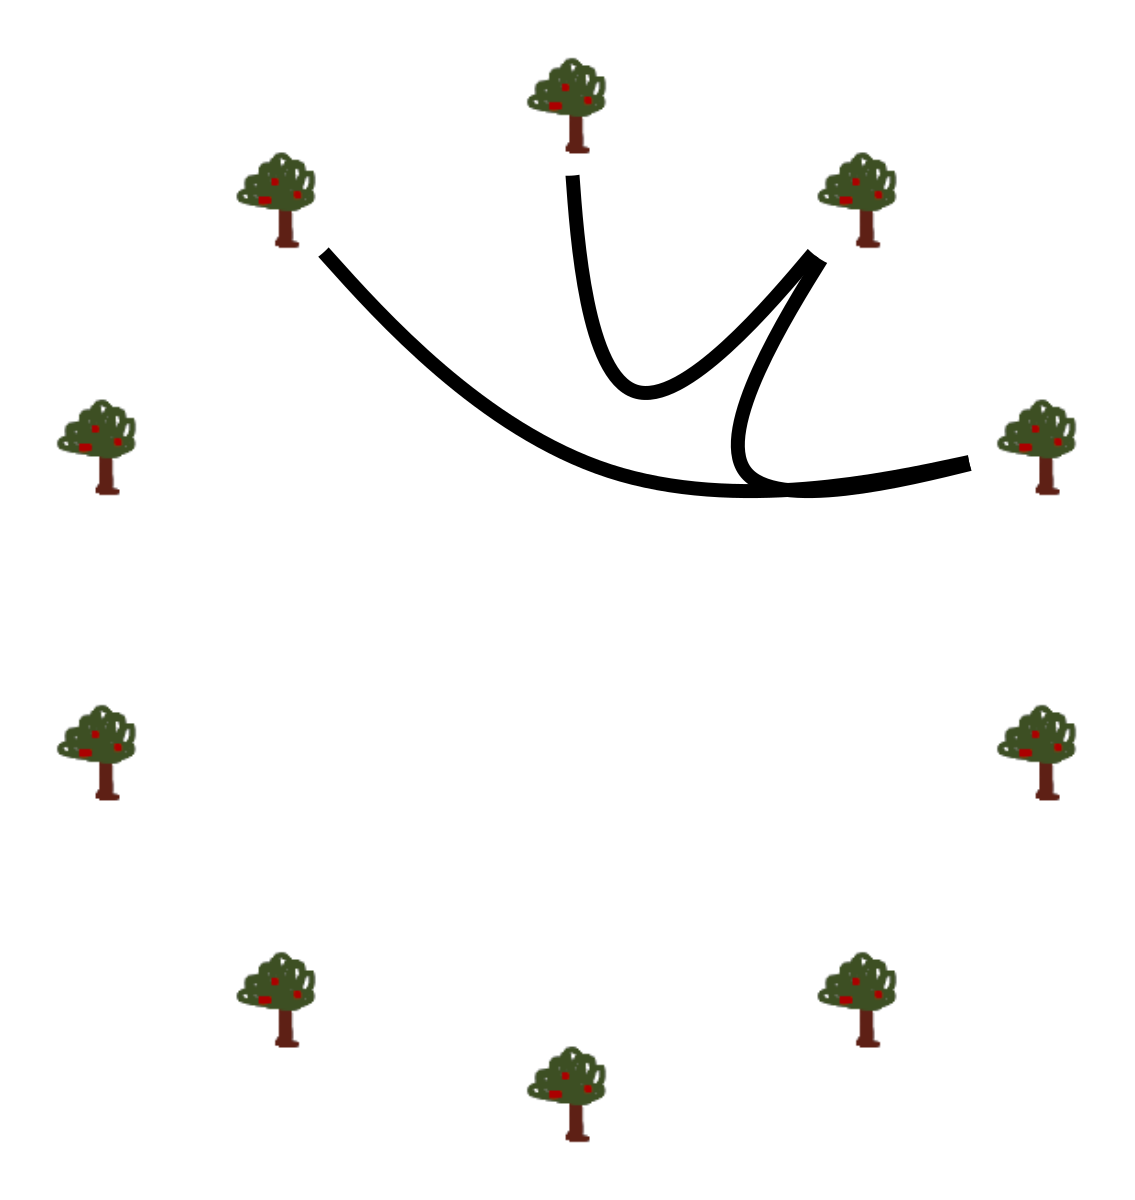

In [ ]:
import graph_tool.all as gt
import cairo
# --- Build two graphs with same vertex set ---
g1 = gt.Graph(directed=False)
g2 = gt.Graph(directed=False)

N = 10
for _ in range(N):
    g1.add_vertex()
    g2.add_vertex()

# Different edge sets
g1.add_edge(0, 1)
g1.add_edge(1, 2)
g1.add_edge(2, 3)

g2.add_edge(0, 2)
g2.add_edge(2, 4)
g2.add_edge(4, 5)

# ARBOLICOS
surface = cairo.ImageSurface.create_from_png("images/arbolico.png")

# Create a property map storing the same surface for each vertex
surf = g1.new_vertex_property("object")
for v in g1.vertices():
    surf[v] = surface


# --- Infer block models ---
state1 = gt.minimize_nested_blockmodel_dl(g1)
state2 = gt.minimize_nested_blockmodel_dl(g2)

# --- Draw the first, capturing positions ---
state_plot = gt.draw_hierarchy(state1, output_size=(600, 600), bg_color=(1, 1, 1, 1), 
                         vprops={'surface':surf, 'color':(0,0,0,0),'fill_color':(0,0,0,0), 'size':70},
                         eprops={'color':'#000000'},
                         hvprops={'color':(0,0,0,1), 'size':0})


In [41]:
pos, _, _ = state_plot

In [232]:
import networkx as nx
import graph_tool.all as gt

# Example NetworkX graph
G_nx = nx.Graph()
G_nx.add_edge(0, 1, weight=1.5)
G_nx.add_edge(1, 2, weight=-2.0)
G_nx.add_edge(2, 0, weight=0.5)

# Convert to graph-tool graph
G_gt = gt.Graph(directed=G_nx.is_directed())

# Add vertices
nx_to_gt = {}
for n in G_nx.nodes():
    v = G_gt.add_vertex()
    nx_to_gt[n] = v

# Add edges and store weights
weight_prop = G_gt.new_edge_property("double")
for u, v, data in G_nx.edges(data=True):
    e = G_gt.add_edge(nx_to_gt[u], nx_to_gt[v])
    weight_prop[e] = data.get("weight", 1.0)

G_gt.ep["weight"] = weight_prop


In [233]:
state = gt.minimize_nested_blockmodel_dl(G_gt, state_args=dict(deg_corr=True))


In [271]:
from matplotlib import colors

edge_color = G_gt.new_edge_property("vector<double>")  # RGB values

for e in G_gt.edges():
    if G_gt.ep["weight"][e] > 0:
        edge_color[e] = (1,1,1,1)  # Blue
    else:
        edge_color[e] = (1,1,1,1)  # Red for negative


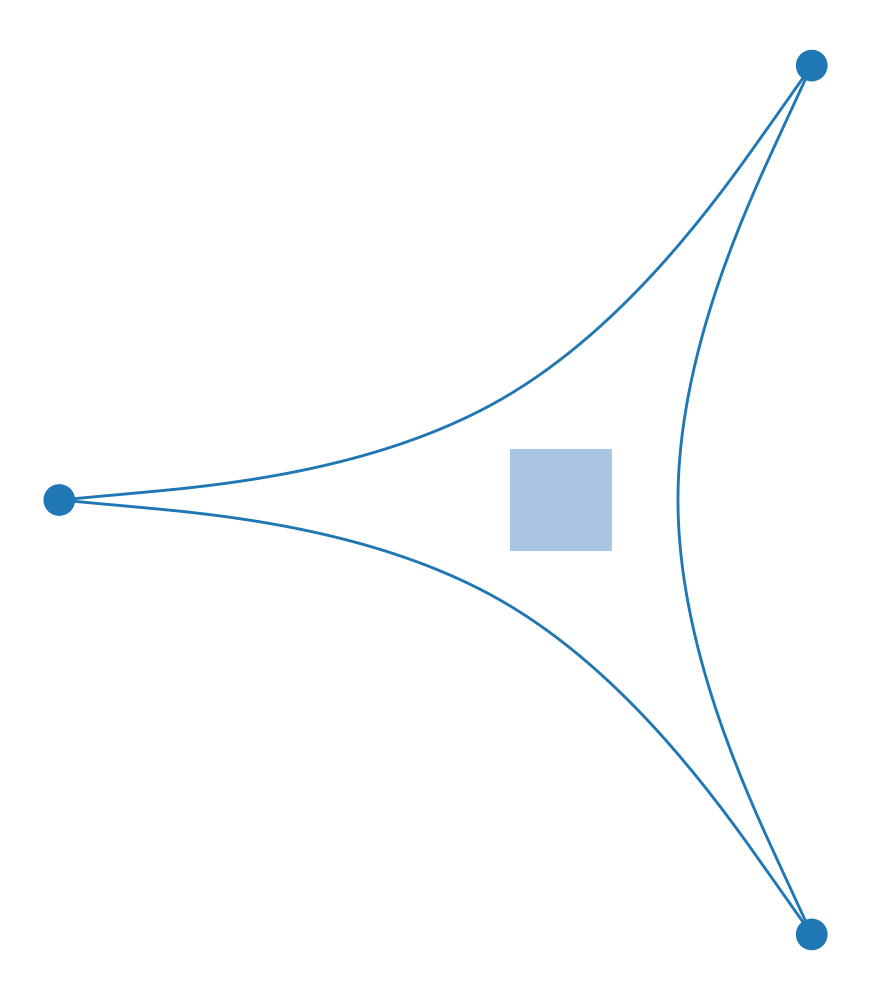

(<VertexPropertyMap object with value type 'vector<double>', for Graph 0x7fea77872670, at 0x7fea77b3f2a0>,
 <GraphView object, directed, with 4 vertices and 3 edges, edges filtered by <EdgePropertyMap object with value type 'bool', for Graph 0x7fea76278f50, at 0x7fea77b3f0e0>, vertices filtered by <VertexPropertyMap object with value type 'bool', for Graph 0x7fea76278f50, at 0x7fea77b3f540>, at 0x7fea76278f50>,
 <VertexPropertyMap object with value type 'vector<double>', for Graph 0x7fea76278f50, at 0x7fea84d89c50>)

In [274]:
state.draw(bg_color=(1, 1, 1, 1), edge_color=edge_color, output_size=(500, 500))
